**Build the comparison table from the saved results**

In [1]:
import sys, json, shutil
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
from src import config

MODEL_NAMES = ["custom_cnn", "resnet50", "efficientnet"]
DISPLAY = {"custom_cnn": "Custom CNN", "resnet50": "ResNet50", "efficientnet": "EfficientNetB0"}

rows = []
for name in MODEL_NAMES:
    with open(config.METRICS_DIR / f"{name}.json") as f:
        r = json.load(f)
    rows.append({
        "Model": DISPLAY[name],
        "Parameters": r["parameters"],
        "Epochs": r["epochs_run"],
        "Training time (min)": round(r["training_time_seconds"] / 60, 1),
        "Val accuracy": r["validation"]["accuracy"],
        "Val F1": r["validation"]["f1_macro"],
        "Test accuracy": r["test"]["accuracy"],
        "Test precision": r["test"]["precision_macro"],
        "Test recall": r["test"]["recall_macro"],
        "Test F1": r["test"]["f1_macro"],
        "Test ROC-AUC": r["test"]["roc_auc_ovr"],
    })

comparison = pd.DataFrame(rows)
comparison.round(3)

,Model,Parameters,Epochs,Training time (min),Val accuracy,Val F1,Test accuracy,Test precision,Test recall,Test F1,Test ROC-AUC
0,Custom CNN,110276,7,36.5,0.574,0.536,0.565,0.585,0.565,0.513,0.808
1,ResNet50,23595908,4,44.3,0.878,0.877,0.811,0.815,0.811,0.803,0.953
2,EfficientNetB0,4054695,6,26.5,0.811,0.797,0.755,0.762,0.755,0.731,0.944


**Save the table and the chart**

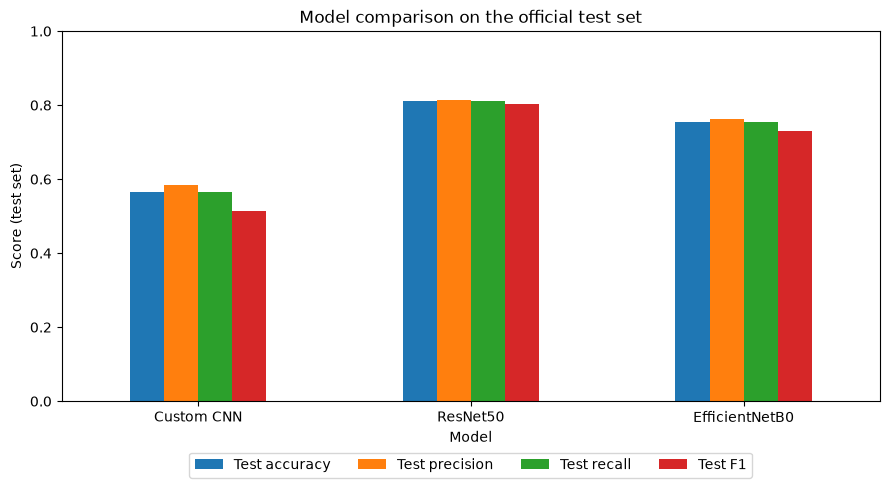

In [4]:
comparison.round(4).to_csv(config.METRICS_DIR / "model_comparison.csv", index=False)

metric_cols = ["Test accuracy", "Test precision", "Test recall", "Test F1"]
ax = comparison.set_index("Model")[metric_cols].plot(kind="bar", figsize=(9, 5), rot=0)
ax.set_ylim(0, 1)
ax.set_ylabel("Score (test set)")
ax.set_title("Model comparison on the official test set")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Select the best model**

In [3]:
best_row = comparison.loc[comparison["Val F1"].idxmax()]
best_display = best_row["Model"]
best_name = [k for k, v in DISPLAY.items() if v == best_display][0]
print("Best model by validation macro-F1:", best_display)
print("Its test accuracy:", round(best_row["Test accuracy"], 3))

# Standard file names used by the prediction pipeline and the app
shutil.copy(config.MODELS_DIR / f"{best_name}.keras", config.MODELS_DIR / "best_model.keras")

with open(config.MODELS_DIR / "class_names.json", "w") as f:
    json.dump(config.CLASS_NAMES, f)

metadata = {
    "selected_model": best_display,
    "model_file": f"{best_name}.keras",
    "input_size": list(config.IMAGE_SIZE),
    "num_classes": config.NUM_CLASSES,
    "selection_rule": "highest validation macro-F1",
    "validation_f1_macro": float(best_row["Val F1"]),
    "test_accuracy": float(best_row["Test accuracy"]),
    "test_f1_macro": float(best_row["Test F1"]),
}
with open(config.MODELS_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

Best model by validation macro-F1: ResNet50
Its test accuracy: 0.811
